In [17]:
import pandas as pd 
import matplotlib.pyplot as plt

In [18]:
#Task 1
import pandas as pd 
 #Load dataset 
df = pd.read_csv("students.csv")

#First 5 rows 
print(df.head())

#2 Shape and data types 
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)

#3 Summary statistics 
print("\nSummary:\n", df.describe())

#4 Pass/Fail Count 
print("\nPass/Fail Count:\n")

#5 Average score per subject BY Pass/Fail
subject_cole = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage (Passed):\n", df[df['passed'] == 1] [subject_cole].mean())
print("\nAverage (Failed):\n", df[df['passed'] == 0] [subject_cole].mean())

#6 Highest Average Studnet 
df['avg_score'] = df[subject_cole].mean(axis=1) 
top_student= df.loc[df['avg_score'].idxmax()]
print("\nTop Student: \n", top_student)



      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data Types:
 name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary:
             math    science    english    history         pe  att

In [19]:
subject_cole=['math', 'science', 'english', 'history', 'pe']
df['avg_score']= df[subject_cole].mean(axis=1)


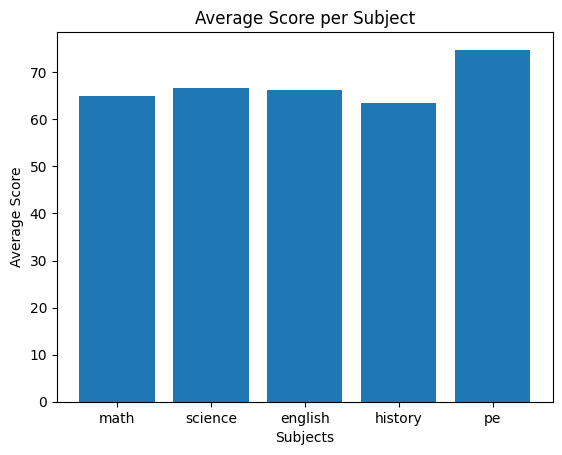

In [20]:
#Task 2
#Bar Chart: AVG Score per subjects 
avg_score= df[subject_cole].mean()
plt.figure()
plt.bar(subject_cole, avg_score)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()


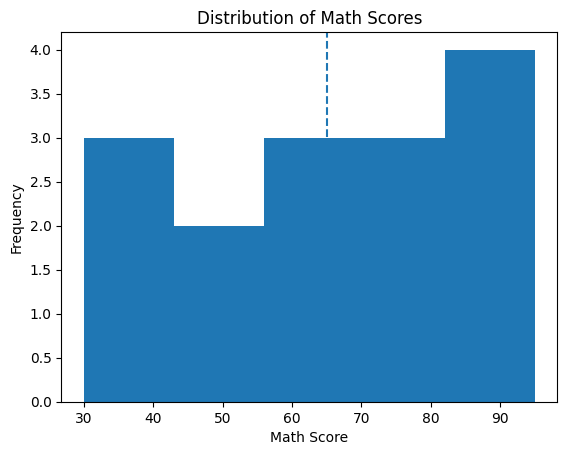

In [21]:
#Histogram: Math Score Distribution

plt.figure()
plt.hist(df['math'], bins=5)
mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed')

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.savefig("plot2_hist.png")
plt.show()



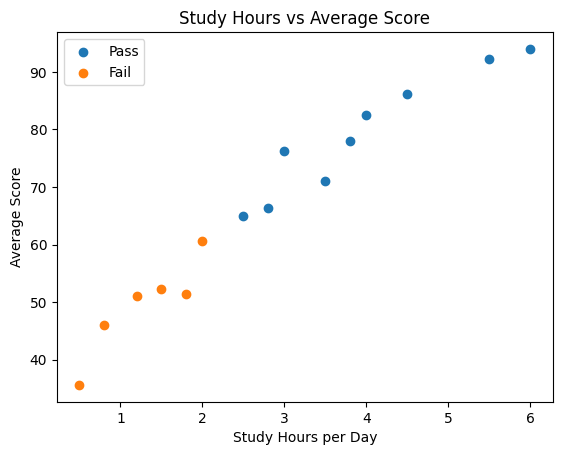

In [22]:
#Scatter Plot: Study hour vs AVG sCORE 
plt.figure()

pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], label='Pass')
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], label='Fail')

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

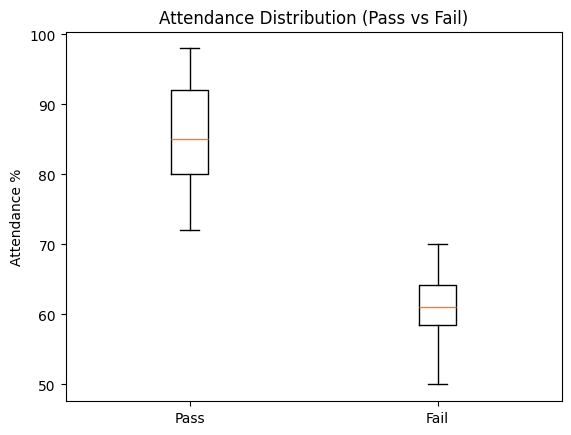

In [23]:
#Box Plot Attendance (PASS/FAIL)
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

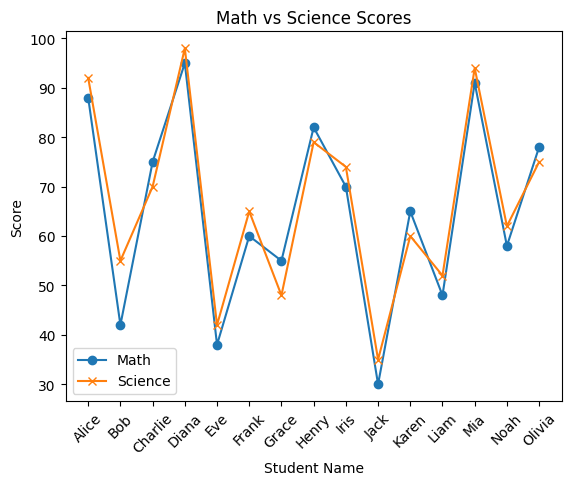

In [24]:
#Line Plot: Math vs Science 
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label= 'Science')

plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()


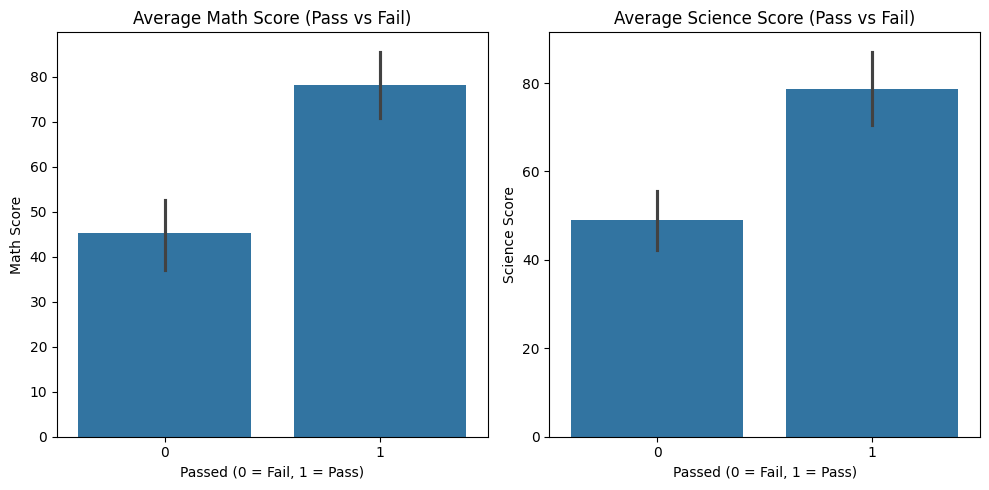

In [25]:
#Task 3 
#Bar Plots 
import seaborn as sns
import matplotlib.pyplot as plt

# Create subplots (2 side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Math plot
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

# Science plot
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

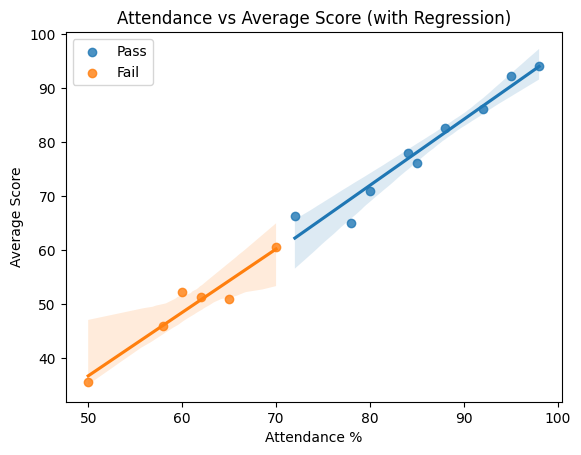

In [26]:
#Scatter and Regression Lines 
plt.figure()

# Pass students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    label='Pass'
)

# Fail students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    label='Fail'
)

plt.title("Attendance vs Average Score (with Regression)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [27]:
# Seaborn was easier to use for statistical plots like barplots and regression lines,
# as it automatically calculates averages and trends. Matplotlib required more manual
# work and setup, but gave more control over customization.

In [28]:
#Task 4 Machine Learning
#Step 1 Prepare Data 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
#Step 2 Train Model 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


In [30]:
#Step 3 Evaluate Model 
# Predictions
y_pred = model.predict(X_test_scaled)

# Test accuracy
test_acc = model.score(X_test_scaled, y_test)
print("\nTest Accuracy:", test_acc)

# Show results with names
print("\nTest Results:")
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {result}")


Test Accuracy: 1.0

Test Results:
Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct



Feature Importance:
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


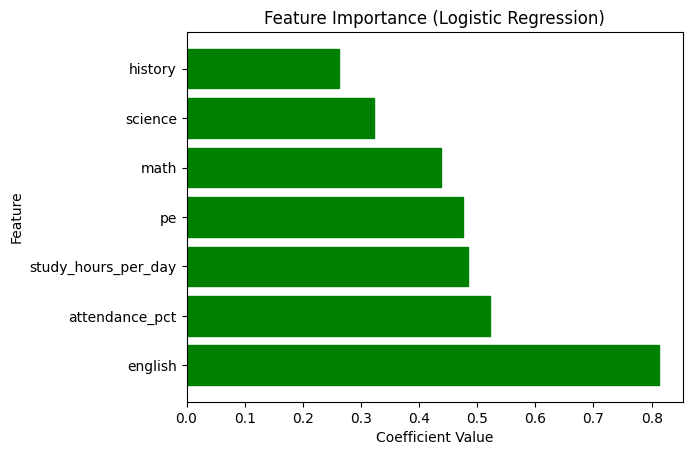

In [31]:
#Step 4 Feature Importance 
import numpy as np
import matplotlib.pyplot as plt

coefficients = model.coef_[0]
features = X.columns

# Pair & sort by absolute value
feature_importance = sorted(
    zip(features, coefficients),
    key=lambda x: abs(x[1]),
    reverse=True
)

print("\nFeature Importance:")
for f, c in feature_importance:
    print(f"{f}: {c:.4f}")

# Plot
features_sorted = [f for f, _ in feature_importance]
coeff_sorted = [c for _, c in feature_importance]

colors = ['green' if c > 0 else 'red' for c in coeff_sorted]

plt.figure()
plt.barh(features_sorted, coeff_sorted)

# Apply colors manually
for i, bar in enumerate(plt.barh(features_sorted, coeff_sorted)):
    bar.set_color(colors[i])

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.savefig("plot8_feature_importance.png")
plt.show()

In [32]:
#Step 5 New Student Prediction 
new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
)

# Scale
new_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:", result)
print("Probability [Fail, Pass]:", probability)


New Student Prediction: Pass
Probability [Fail, Pass]: [0.09203526 0.90796474]
